In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/yerba-mate-1970-2024.csv", encoding="latin-1")

df.head()

,cultivo,anio,campania,provincia,provincia_id,departamento,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha
0,yerba mate,1970,1969/1970,Corrientes,18,Ituzaingó,18084,3470,1106,2375,2147
1,yerba mate,1970,1969/1970,Corrientes,18,Santo Tomé,18168,5205,1661,3564,2146
2,yerba mate,1970,1969/1970,Misiones,54,Apóstoles,54007,11784,3052,5150,1687
3,yerba mate,1970,1969/1970,Misiones,54,Cainguás,54014,6078,1566,3568,2278
4,yerba mate,1970,1969/1970,Misiones,54,Candelaria,54021,3298,872,1020,1170


In [3]:
df_anual = df.groupby("anio")["produccion_tm"].sum().reset_index()

df_anual.head()

,anio,produccion_tm
0,1970,76788
1,1971,90460
2,1972,126714
3,1973,150963
4,1974,134529


In [4]:
df_modelo = df_anual[df_anual["anio"] >= 2000].copy()

df_modelo.head()

,anio,produccion_tm
30,2000,670399
31,2001,684597
32,2002,695400
33,2003,775591
34,2004,749200


In [5]:
X = df_modelo[["anio"]]
y = df_modelo["produccion_tm"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

print("Pendiente (m):", pendiente)
print("Intercepto (b):", intercepto)

Pendiente (m): 6400.970852465562
Intercepto (b): -12091565.752245957


In [9]:
score = modelo.score(X_test, y_test)
print("R²:", score)

R²: 0.15810991759297488


In [10]:
import numpy as np

anios_futuros = np.array([[2025], [2026], [2027], [2028], [2029], [2030]])

predicciones = modelo.predict(anios_futuros)

for anio, pred in zip(anios_futuros.flatten(), predicciones):
    print(f"Año {anio}: {int(pred):,} toneladas")

Año 2025: 870,400 toneladas
Año 2026: 876,801 toneladas
Año 2027: 883,202 toneladas
Año 2028: 889,603 toneladas
Año 2029: 896,004 toneladas
Año 2030: 902,405 toneladas


C:\Users\giank\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


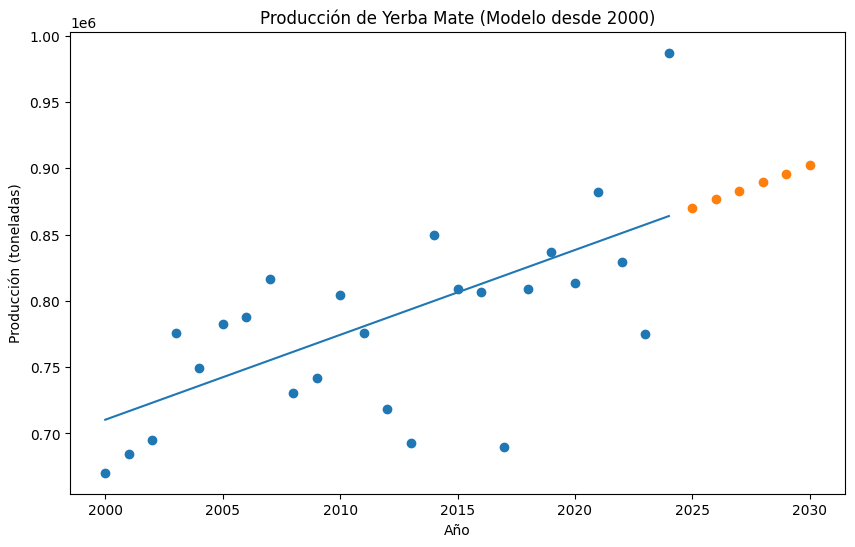

In [11]:
plt.figure(figsize=(10,6))

# Datos reales desde 2000
plt.scatter(X, y)

# Línea de regresión
plt.plot(X, modelo.predict(X))

# Predicciones futuras
plt.scatter(anios_futuros, predicciones)

plt.title("Producción de Yerba Mate (Modelo desde 2000)")
plt.xlabel("Año")
plt.ylabel("Producción (toneladas)")
plt.show()

In [12]:
prod_2000 = df_anual[df_anual["anio"] == 2000]["produccion_tm"].values[0]
prod_2024 = df_anual[df_anual["anio"] == 2024]["produccion_tm"].values[0]

print("Producción 2000:", int(prod_2000))
print("Producción 2024:", int(prod_2024))

Producción 2000: 670399
Producción 2024: 987180


In [13]:
crecimiento_absoluto = prod_2024 - prod_2000
print("Crecimiento absoluto:", int(crecimiento_absoluto), "toneladas")

Crecimiento absoluto: 316781 toneladas


In [14]:
crecimiento_porcentual = ((prod_2024 - prod_2000) / prod_2000) * 100
print("Crecimiento porcentual:", round(crecimiento_porcentual, 2), "%")

Crecimiento porcentual: 47.25 %


In [15]:
crecimiento_promedio_anual = crecimiento_absoluto / 24
print("Crecimiento promedio anual:", int(crecimiento_promedio_anual), "toneladas por año")

Crecimiento promedio anual: 13199 toneladas por año
